In [184]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 

In [185]:

# I am loading the dataset directly from my GitHub repository.
file_Url='https://raw.githubusercontent.com/Nkengfack/Bank_marketing_ml_Classifications/refs/heads/main/bank_marketing_dataset.csv'


In [186]:
# The file uses semicolons as separators rather than commas, 
marketing=pd.read_csv(file_Url, sep=';', )
# Showing all columns matters here because the dataset has 21 columns
# and pandas tends to hide the middle ones by default
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [187]:
#checking to see if the data will load correctly
marketing.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


In [188]:
# The original target column is simply called 'y' in the marketing dataset.
# Renaming it to 'subscribed' makes the code easier fo me to follow throughout. 
TARGET = 'subscribed'
marketing.rename(columns={'y': TARGET}, inplace=True)
print(f'Dataset loaded successfully from GitHub.')
print(f'Rows     : {marketing.shape[0]:,}')
print(f'Columns  : {marketing.shape[1]}')
print(f'Features : {marketing.shape[1] - 1}  (excluding target column)')
print(f'Target   : {TARGET}  (yes = subscribed,  no = did not subscribe)')
print(f'\nColumn names:')
print(marketing.columns.tolist())
 

Dataset loaded successfully from GitHub.
Rows     : 41,188
Columns  : 21
Features : 20  (excluding target column)
Target   : subscribed  (yes = subscribed,  no = did not subscribe)

Column names:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'subscribed']


In [189]:
# checking if the 'y' culmn has change
marketing.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.10,94.77,-50.80,1.03,4963.60,no


In [190]:
#  CELL 4: Data Types and Structure 
# For this dataset, I already know there are no NaN values, but I still
# run this because it confirms the data types I need for preprocessing.
 
marketing.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [191]:
#  CELL 5: Summary Statistics for Numerical Columns 
# describe() calculates count, mean, standard deviation, min, quartiles
# and max for every numerical column. This goes into the report as Figure 3.1.
# I pay close attention to columns where the max is extremely high compared
# to the 75th percentile — that gap usually signals outliers.
 
print('Summary Statistics, Numerical Features (Figure 3.1)')
#print('=' * 60)
marketing.describe()
 

Summary Statistics, Numerical Features (Figure 3.1)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [192]:
# ── CELL 6: Summary Statistics for Categorical Columns ───────────────────────
# By default describe() skips text columns, so I pass include='object'
# to see them separately. The 'top' row shows the most frequent value
# and 'freq' shows how many times it appears. This is where I can already
# see 'no' dominating the subscribed column.
 
print('Summary Statistics — Categorical Features')
print('=' * 60)
marketing.describe(include='object')
 

Summary Statistics — Categorical Features


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,subscribed
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [193]:
import pandas as pd

print('Columns containing unknown values')
print('=' * 60)

# I only want to check categorical columns since numerical ones
# cannot contain the string 'unknown'.
cat_cols = [col for col in marketing.columns if marketing[col].dtype == 'object' and col != TARGET]

unknown_summary = {}
for col in cat_cols:
    count = (marketing[col] == 'unknown').sum()
    pct = round(count / len(marketing) * 100, 2)
    if count > 0:
        unknown_summary[col] = {
            'Unknown Count': count,
            'Unknown (%)': pct
        }

if unknown_summary:
    unknown_df = pd.DataFrame(unknown_summary).T
    print(unknown_df.to_string())
    print(f'\nTotal unknown entries across all columns: {unknown_df["Unknown Count"].sum():,.0f}')
else:
    print('No columns contain the string "unknown".')

print('\nNote: default has the highest proportion at over 20%.')
print('These will be kept as a separate category during preprocessing')
print('rather than dropped, to avoid losing too many records.')


Columns containing unknown values
No columns contain the string "unknown".

Note: default has the highest proportion at over 20%.
These will be kept as a separate category during preprocessing
rather than dropped, to avoid losing too many records.


In [194]:
#  CELL 7: Detecting Hidden Missing Values 
# This dataset has no NaN values at all, which looks clean on the surface.
# However, several columns use the string 'unknown' as a placeholder,
# which behaves exactly like a missing value but is invisible to isnull().
# I check every column except the target for 'unknown' entries.
# Rather than filtering by dtype first, I check all columns directly
# because numerical columns will simply return zero and get excluded
# by the count > 0 condition below.

print('Columns containing unknown values')
print('=' * 60)

unknown_summary = {}

for col in marketing.columns:
    if col == TARGET:
        continue
    try:
        count = (marketing[col] == 'unknown').sum()
        pct   = round(count / len(marketing) * 100, 2)
        if count > 0:unknown_summary[col] = {'Unknown Count':count, 'Unknown (%)': pct}
    except TypeError:
        # Skip any column where string comparison is not possible
       continue

if unknown_summary:
    unknown_df = pd.DataFrame(unknown_summary).T
    print(unknown_df.to_string())
    print(f'\nTotal unknown entries across all columns: '
          f'{unknown_df["Unknown Count"].sum():,.0f}')
else:
    print('No columns contain the string "unknown".')

print('\nNote: default has the highest proportion at over 20%.')
print('These will be kept as a separate category during preprocessing')
print('rather than dropped, to avoid losing too many records.')

Columns containing unknown values
           Unknown Count  Unknown (%)
job               330.00         0.80
marital            80.00         0.19
education        1731.00         4.20
default          8597.00        20.87
housing           990.00         2.40
loan              990.00         2.40

Total unknown entries across all columns: 12,718

Note: default has the highest proportion at over 20%.
These will be kept as a separate category during preprocessing
rather than dropped, to avoid losing too many records.


In [195]:
# Check through every column and print the count of 'unknown' values
for col in marketing.columns:
    count = (marketing[col] == 'unknown').sum()
    if count > 0:
        print(f'{col}: {count} unknowns')


job: 330 unknowns
marital: 80 unknowns
education: 1731 unknowns
default: 8597 unknowns
housing: 990 unknowns
loan: 990 unknowns


In [196]:
# ── CELL 8: The pdays Column — A Special Case ─────────────────────────────────
# pdays stores how many days passed since a client was last contacted
# in a previous campaign. The value 999 is a sentinel — it means the
# client was never previously contacted at all, not that they were
# contacted 999 days ago. Treating 999 as a real number would
# completely mislead any model using this feature.
# The solution is to create a binary flag in preprocessing and drop pdays.
 
never_contacted = (marketing['pdays'] == 999).sum()
was_contacted   = (marketing['pdays'] != 999).sum()
 
print('pdays Column Analysis')
print('=' * 60)
print(f'pdays = 999 (never contacted) : {never_contacted:,}  '
      f'({never_contacted / len(marketing) * 100:.1f}%)')
print(f'pdays < 999 (was contacted)   : {was_contacted:,}  '
      f'({was_contacted / len(marketing) * 100:.1f}%)')
print()
print('96.3% of records have pdays = 999.')
print('In preprocessing I will create a new binary column')
print("'was_previously_contacted' (1 = yes, 0 = no)")
print('and drop the original pdays column entirely.')
 

pdays Column Analysis
pdays = 999 (never contacted) : 39,673  (96.3%)
pdays < 999 (was contacted)   : 1,515  (3.7%)

96.3% of records have pdays = 999.
In preprocessing I will create a new binary column
'was_previously_contacted' (1 = yes, 0 = no)
and drop the original pdays column entirely.


In [197]:
# ── CELL 9: Removing Duplicate Records ───────────────────────────────────────
# Duplicate rows will skew the distributions
# I am about to plot, and they give the model repeated exposure to the
# same records during training which introduces bias.

 
duplicates_found = marketing.duplicated().sum()
print(f'Duplicate rows found: {duplicates_found}')
 
marketing.drop_duplicates(keep='first', ignore_index=True, inplace=True)
 
print(f'Duplicates removed.')
print(f'Dataset now has {len(marketing):,} rows.')
 

Duplicate rows found: 12
Duplicates removed.
Dataset now has 41,176 rows.


In [198]:
# ── CELL 10: Organising Columns by Type ──────────────────────────────────────
# I separate the columns into numerical and categorical lists here
# because I will reuse both lists constantly throughout the notebook.
# Defining them once avoids repeating the same select_dtypes call
# in every subsequent cell.
 
num_features = marketing.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()
 
cat_features = [
    col for col in marketing.select_dtypes(include='object').columns.tolist()
    if col != TARGET
]
 
print(f'Numerical features ({len(num_features)}):')
for col in num_features:
    print(f'  {col}')
 
print(f'\nCategorical features ({len(cat_features)}):')
for col in cat_features:
    print(f'  {col}')
 
print(f'\nTarget column: {TARGET}  (binary — yes / no)')

Numerical features (10):
  age
  duration
  campaign
  pdays
  previous
  emp.var.rate
  cons.price.idx
  cons.conf.idx
  euribor3m
  nr.employed

Categorical features (10):
  job
  marital
  education
  default
  housing
  loan
  contact
  month
  day_of_week
  poutcome

Target column: subscribed  (binary — yes / no)


Target Variable — Class Distribution
            Count  Percentage (%)
subscribed                       
no          36537           88.73
yes          4639           11.27


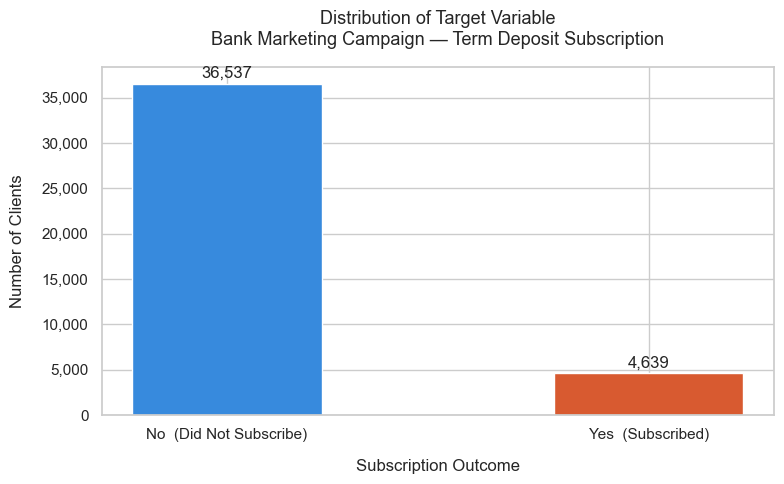


Class imbalance: 88.7% no  vs  11.3% yes
This imbalance will be addressed using SMOTE in Part 2.


In [199]:
# ── CELL 11: Class Distribution of the Target Variable (Figure 3.2) ──────────
# The chart shows immediately that the dataset is heavily imbalanced —
# 88.7% of clients did not subscribe compared to only 11.3% who did.
# This single finding justifies SMOTE, the metric selection (F1, MCC),
# and the pipeline design.
 
counts = marketing[TARGET].value_counts()
pcts   = marketing[TARGET].value_counts(normalize=True) * 100
 
print('Target Variable — Class Distribution')
print('=' * 45)
print(pd.DataFrame({
    'Count'         : counts,
    'Percentage (%)': pcts.round(2)}))
 
fig, ax = plt.subplots(figsize=(8, 5))
 
bars = ax.bar(
    ['No  (Did Not Subscribe)', 'Yes  (Subscribed)'],
    counts.values,
    color=PALETTE,
    width=0.45,
    edgecolor='white'
)
 
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 280,
        f'{bar.get_height():,}',
        ha='center', va='bottom',
        fontsize=12, fontweight='medium')

ax.set_title('Distribution of Target Variable\n'
             'Bank Marketing Campaign — Term Deposit Subscription', pad=16, fontsize=13)
ax.set_xlabel('Subscription Outcome', labelpad=12)
ax.set_ylabel('Number of Clients', labelpad=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
#sns.despine(top=True, right=True)
#ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('fig_3_2_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nClass imbalance: {pcts['no']:.1f}% no  vs  {pcts['yes']:.1f}% yes")
print('This imbalance will be addressed using SMOTE in Part 2.')
 
 

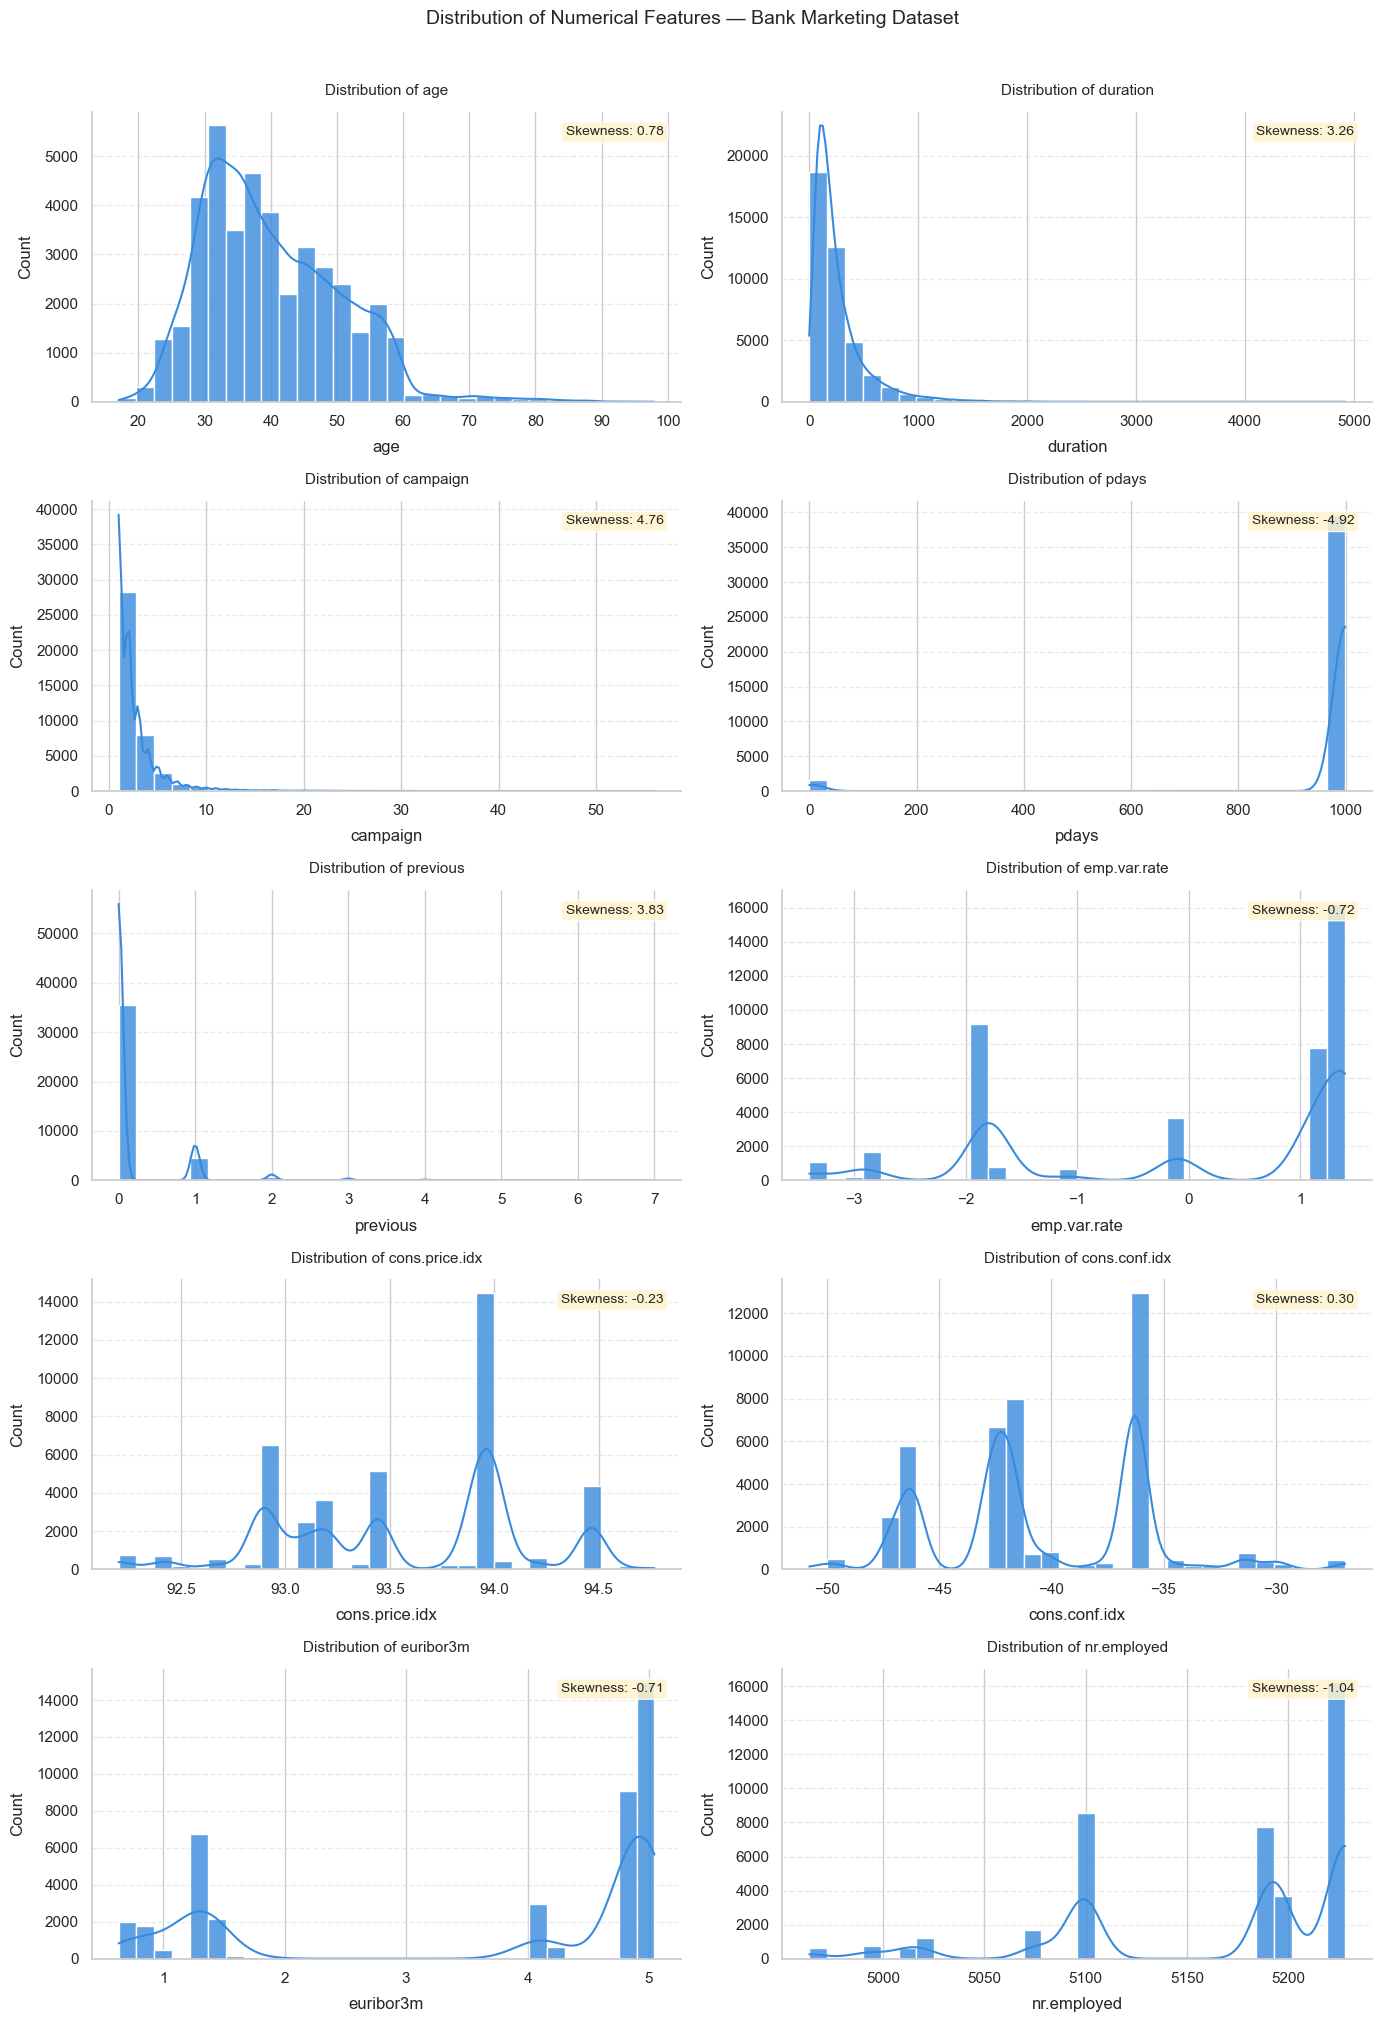

In [200]:
# ── CELL 12: Distribution of Numerical Features ──────────────────────────────
# I plot a histogram with a KDE curve for every numerical feature.
# The skewness value on each chart tells me how symmetric the distribution
# is. Anything above 1.0 or below -1.0 is worth noting in the report
# because it affects which scaler I should use in preprocessing.
# I also keep an eye out for bimodal distributions or unusual spikes
# that might indicate data quality issues.
 
n_cols = 2
n_rows = (len(num_features) + 1) // n_cols
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()
 
for i, col in enumerate(num_features):
    ax = axes[i]
    sns.histplot(
        marketing[col], kde=True, bins=30,
        ax=ax, color=COLOUR_NO, alpha=0.8)
 
    skew_val = marketing[col].skew()
    ax.text(
        0.97, 0.95,
        f'Skewness: {skew_val:.2f}',
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='#FFF3CD',
            alpha=0.85
        )
    )
    ax.set_title(f'Distribution of {col}', pad=12, fontsize=11)
    ax.set_xlabel(col, labelpad=8)
    ax.set_ylabel('Count', labelpad=8)
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle(
    'Distribution of Numerical Features — Bank Marketing Dataset',
    fontsize=14, y=1.01, fontweight='medium'
)
plt.tight_layout()
plt.savefig('fig_numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

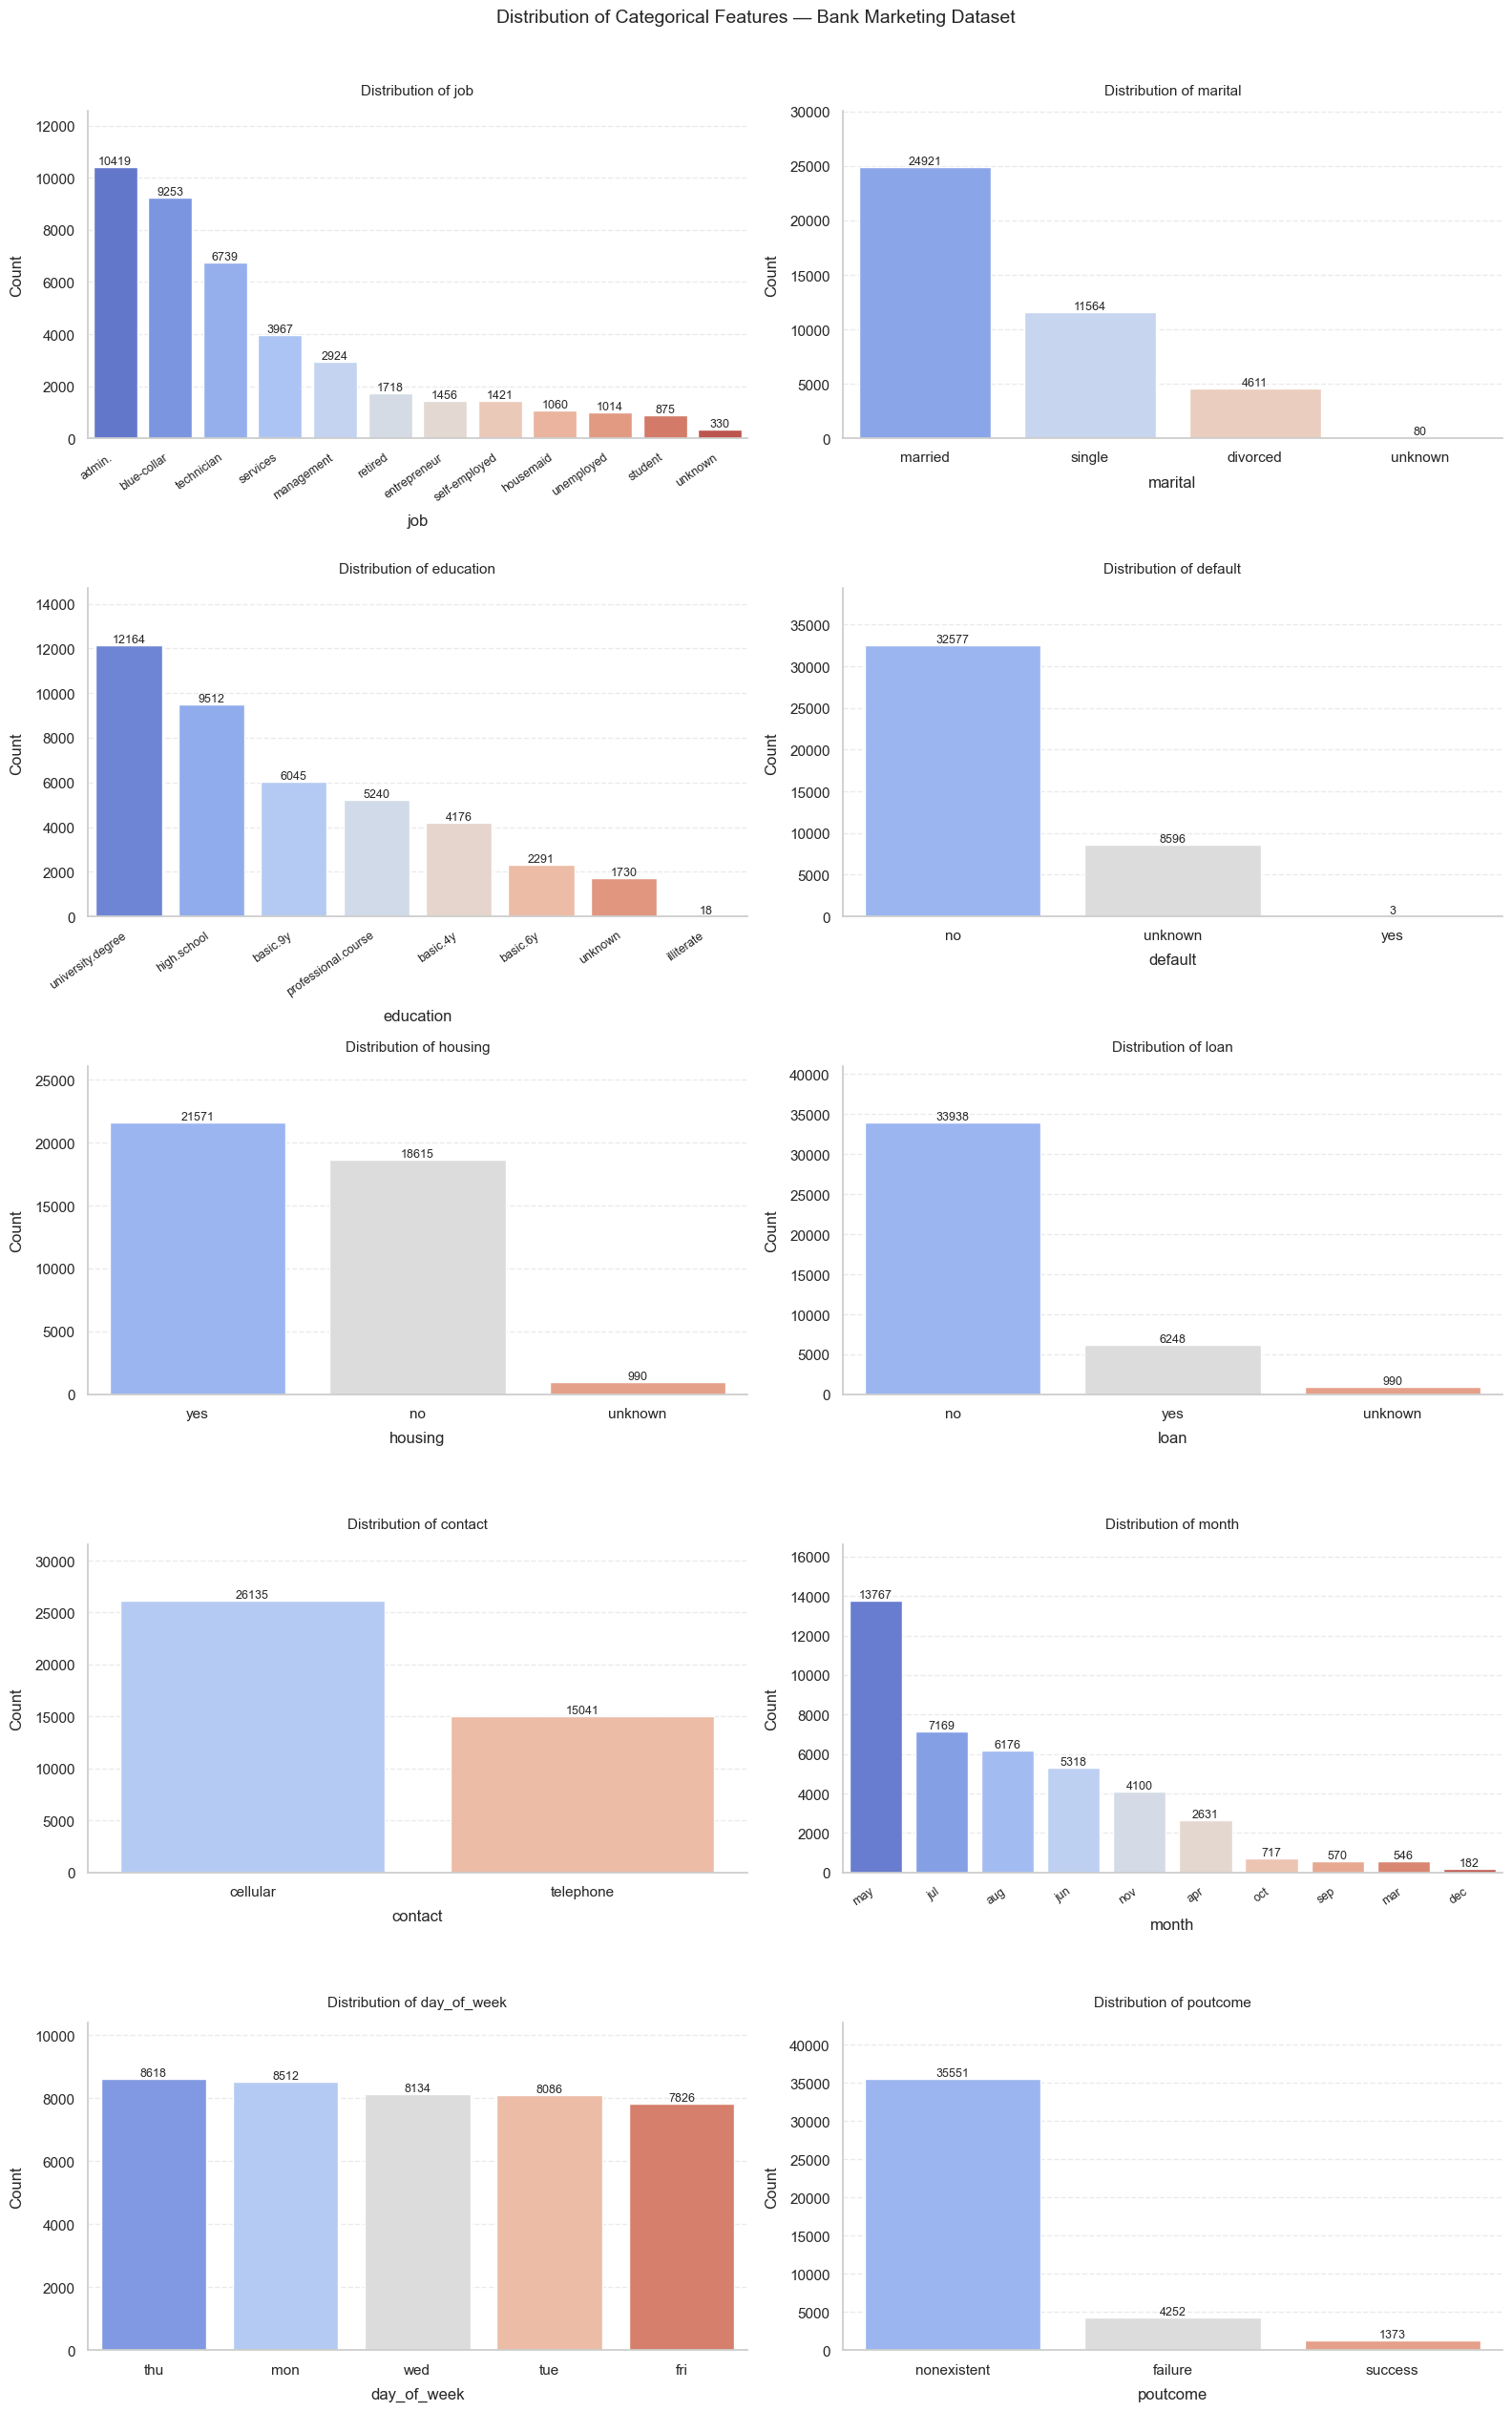

In [201]:
# ── CELL 13: Distribution of Categorical Features ────────────────────────────
# Count plots for every categorical feature, sorted from most to least
# frequent so the dominant categories stand out immediately.
# I add count labels on each bar because the report figures need to be
# readable without having to estimate from the axis scale.
# The 'unknown' category is visible in several charts here, which
# reinforces the decision documented in Cell 7.
 
n_cols = 2
n_rows = (len(cat_features) + 1) // n_cols
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()
 
for i, col in enumerate(cat_features):
    ax = axes[i]
    order = marketing[col].value_counts().index
 
    sns.countplot(
        data=marketing, x=col,
        order=order, ax=ax,
        palette='coolwarm',
        edgecolor='white'
    )
 
    if marketing[col].nunique() > 5:
        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=35, ha='right', fontsize=9
        )
 
    for container in ax.containers:
        ax.bar_label(
            container, fmt='%d',
            label_type='edge', fontsize=9
        )
 
    ax.set_title(f'Distribution of {col}', pad=12, fontsize=11)
    ax.set_xlabel(col, labelpad=8)
    ax.set_ylabel('Count', labelpad=8)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle(
    'Distribution of Categorical Features — Bank Marketing Dataset',
    fontsize=14, y=1.01, fontweight='medium'
)
plt.tight_layout()
plt.savefig('fig_categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
 


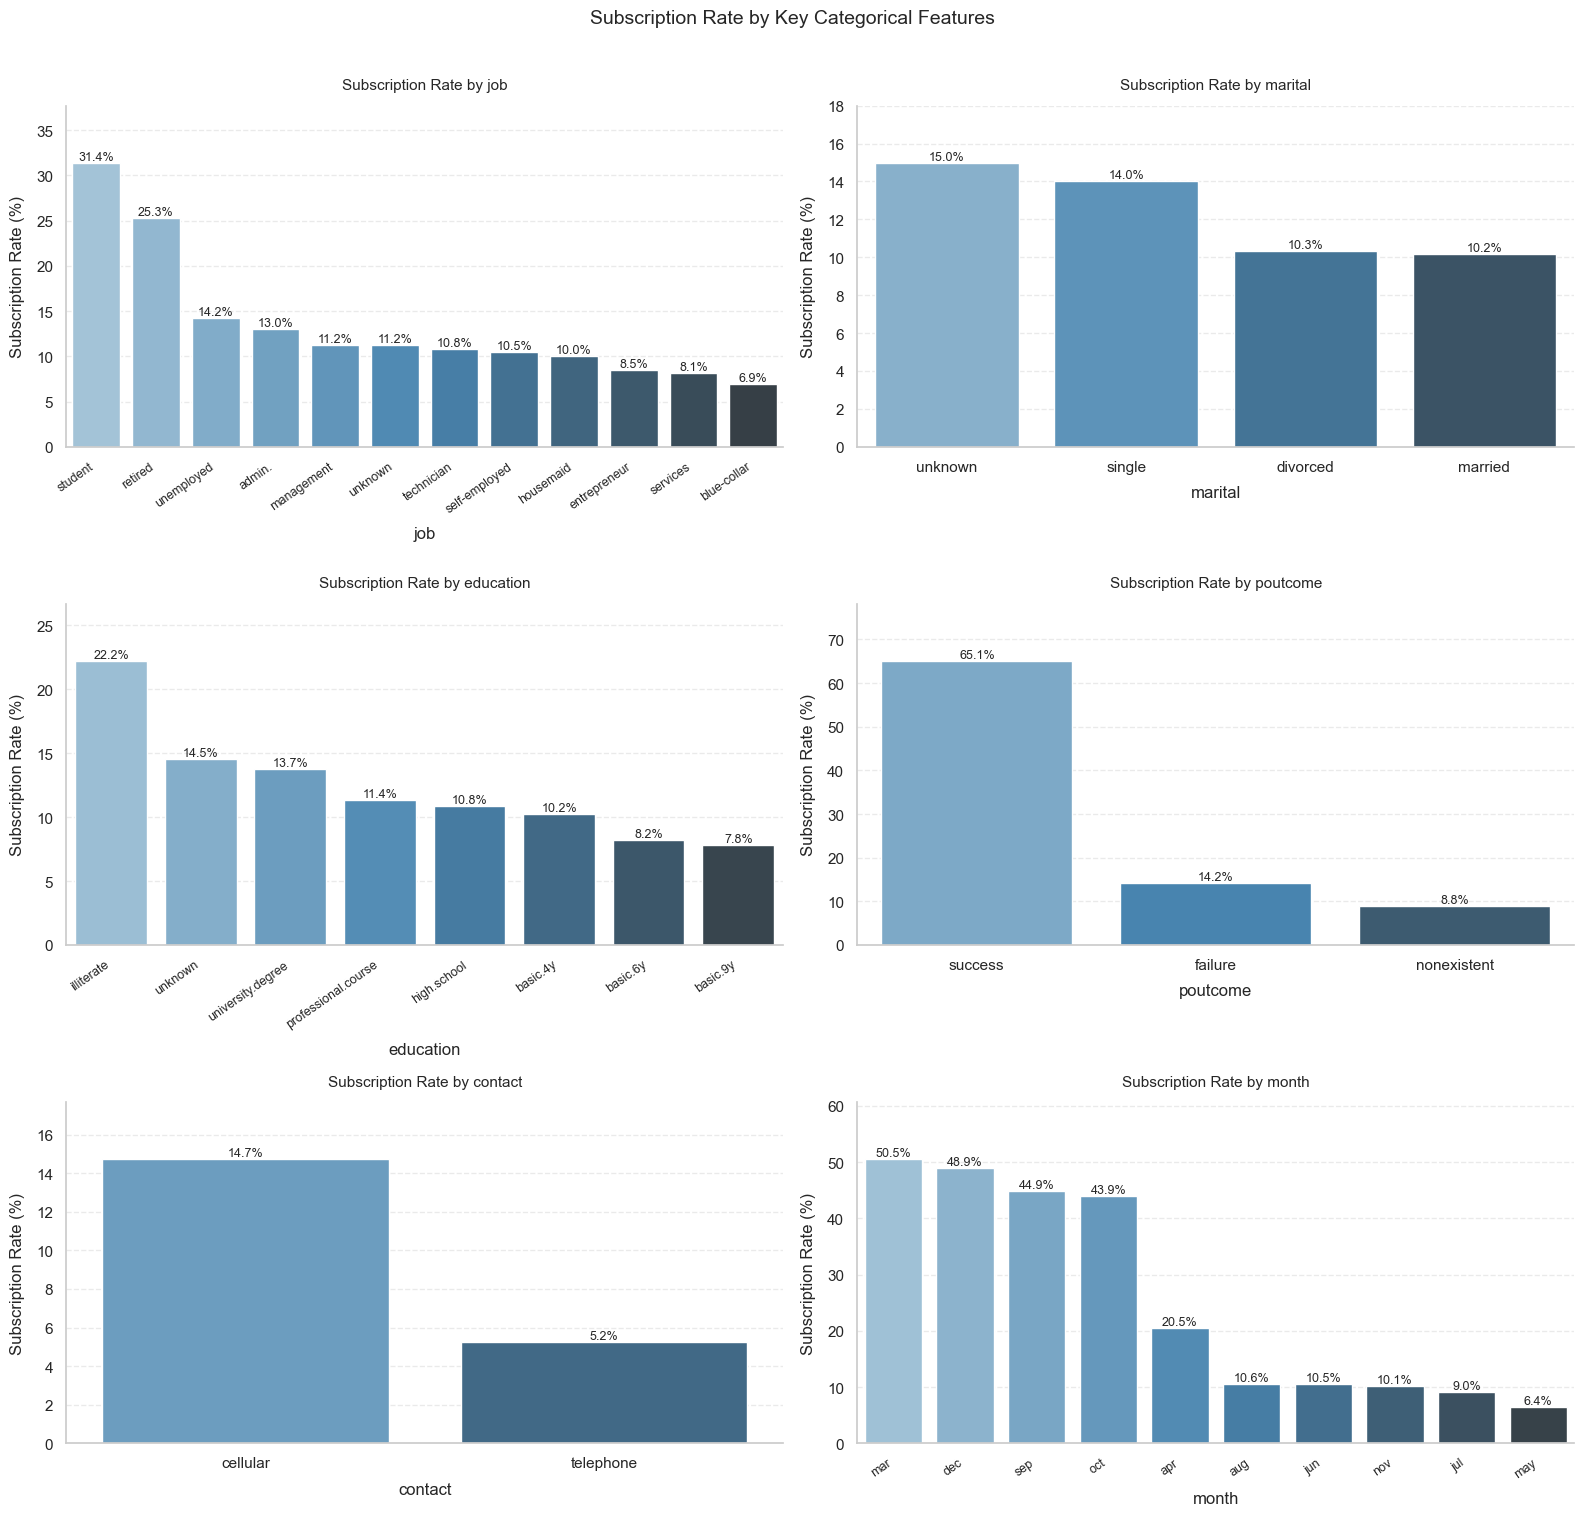

In [210]:
# ── CELL 14: Subscription Rate by Key Categorical Features ───────────────────
# Rather than just counting how many clients fall into each category,
# I want to know which categories are most associated with subscribing.
# This feeds directly into the feature importance discussion later —
# I expect poutcome_success and cellular contact to stand out strongly
# even before any model has been trained.
 
key_cats = ['job', 'marital', 'education', 'poutcome', 'contact', 'month']
 
n_cols = 2
n_rows = (len(key_cats) + 1) // n_cols
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()
 
for i, col in enumerate(key_cats):
    ax = axes[i]
 
    rate = (
        marketing.groupby(col)[TARGET]
        .apply(lambda x: (x == 'yes').mean() * 100)
        .sort_values(ascending=False)
        .reset_index())
    rate.columns = [col, 'subscription_rate']
 
    sns.barplot(data=rate, x=col,y='subscription_rate',ax=ax, palette='Blues_d',edgecolor='white')
 
    if marketing[col].nunique() > 4:
        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=35, ha='right', fontsize=9)
 
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%',label_type='edge', fontsize=9)
 
    ax.set_title(f'Subscription Rate by {col}',pad=12, fontsize=11)
    ax.set_xlabel(col, labelpad=8)
    ax.set_ylabel('Subscription Rate (%)', labelpad=8)
    ax.set_ylim(0, rate['subscription_rate'].max() * 1.2)
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle(
    'Subscription Rate by Key Categorical Features',
    fontsize=14, y=1.01, fontweight='medium'
)
plt.tight_layout()
plt.savefig('fig_subscription_rate_by_category.png', dpi=300, bbox_inches='tight')
plt.show()
 
 

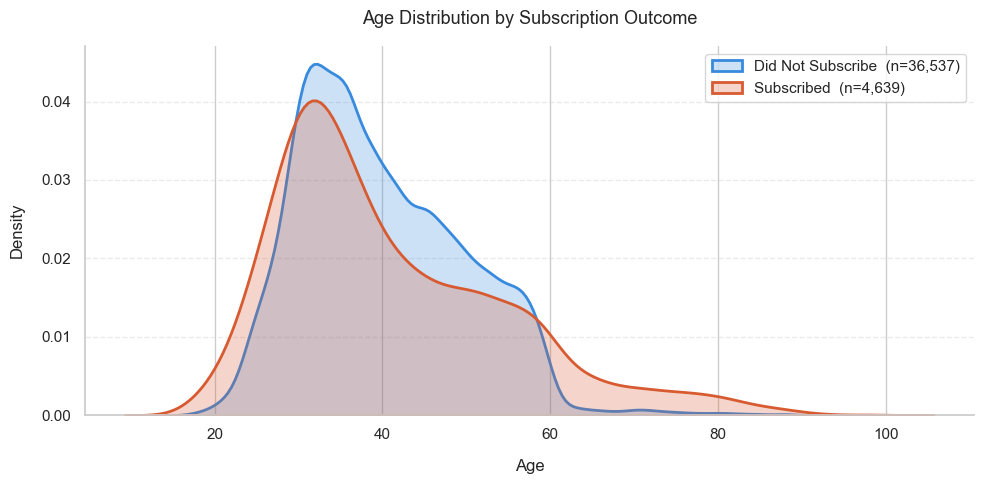

In [203]:
# ── CELL 15: Age Distribution by Subscription Outcome ────────────────────────
# Age is one of the most intuitive features in this dataset so I want
# to see whether the age distribution differs between subscribers and
# non-subscribers. A KDE plot with both classes overlaid makes this
# comparison very clear and produces a clean figure for the report.
 
fig, ax = plt.subplots(figsize=(10, 5))
 
for outcome, colour, label in [
    ('no',  COLOUR_NO,  'Did Not Subscribe'),
    ('yes', COLOUR_YES, 'Subscribed')
]:
    subset = marketing[marketing[TARGET] == outcome]['age']
    sns.kdeplot(subset, ax=ax,color=colour,label=f'{label}  (n={len(subset):,})',linewidth=2, fill=True, alpha=0.25)
 
ax.set_title('Age Distribution by Subscription Outcome',pad=16, fontsize=13)
ax.set_xlabel('Age', labelpad=12)
ax.set_ylabel('Density', labelpad=12)
ax.legend(fontsize=11)
sns.despine(top=True, right=True)
ax.grid(axis='y', linestyle='--', alpha=0.4)
 
plt.tight_layout()
plt.savefig('fig_age_by_subscription.png', dpi=300, bbox_inches='tight')
plt.show()

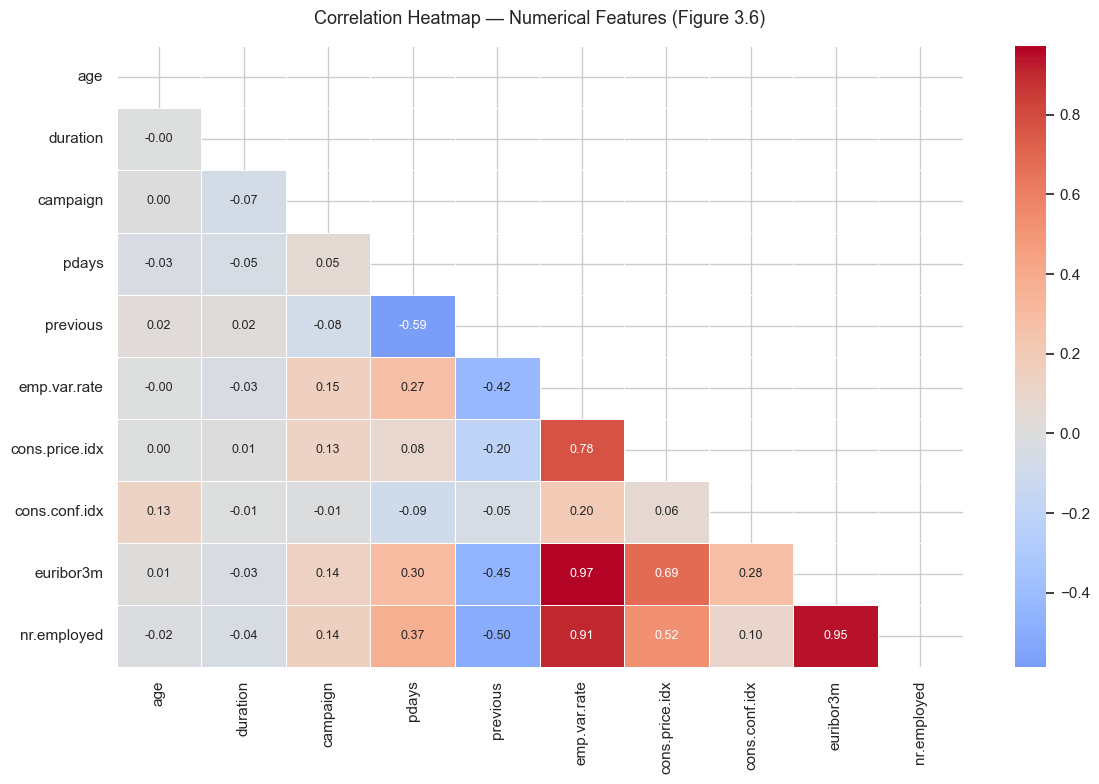

Strong correlations found (|r| > 0.70):
  cons.price.idx  <-->  emp.var.rate  :  r = 0.775
  euribor3m  <-->  emp.var.rate  :  r = 0.972
  nr.employed  <-->  emp.var.rate  :  r = 0.907
  nr.employed  <-->  euribor3m  :  r = 0.945

The strong correlations between the economic indicators
(euribor3m, emp.var.rate, nr.employed) are expected because
they all reflect the state of the economy at the same point
in time. This multicollinearity is discussed in Section 3.2.4.


In [204]:
# ── CELL 16: Correlation Heatmap — Numerical Features (Figure 3.6) ───────────
# The heatmap shows the correlation coefficient between every pair of
# numerical features. I mask the upper triangle because it is a mirror
# of the lower one and showing both just adds visual noise.
# The economic indicator columns are the most interesting ones to watch
# here — I expect strong correlations between euribor3m, emp.var.rate,
# and nr.employed because they all measure the economy at the same time.
 
fig, ax = plt.subplots(figsize=(12, 8))
corr_matrix = marketing[num_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,mask=mask,annot=True,fmt='.2f',cmap='coolwarm',center=0,linewidths=0.5,ax=ax,annot_kws={'size': 9})
ax.set_title('Correlation Heatmap — Numerical Features (Figure 3.6)',pad=16, fontsize=13)
plt.tight_layout()
plt.savefig('fig_3_6_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Strong correlations found (|r| > 0.70):')
strong_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.70:
            strong_pairs.append(
                (corr_matrix.columns[i],
                 corr_matrix.columns[j],
                 round(r, 3))
            )
 
if strong_pairs:
    for pair in strong_pairs:
        print(f'  {pair[0]}  <-->  {pair[1]}  :  r = {pair[2]}')
else:
    print('  No strongly correlated pairs found.')
 
print()
print('The strong correlations between the economic indicators')
print('(euribor3m, emp.var.rate, nr.employed) are expected because')
print('they all reflect the state of the economy at the same point')
print('in time. This multicollinearity is discussed in Section 3.2.4.')

In [205]:
# ── CELL 17: Outlier Detection Using the IQR Method (Table 3.3) ──────────────
# I use the Interquartile Range method to identify outliers rather than
# standard deviation because several features in this dataset are heavily
# skewed, and the IQR method does not assume a normal distribution.
# The results feed directly into Table 3.3 of the report and justify
# the outlier removal step in Part 2 preprocessing.
 
print('Outlier Detection Summary — IQR Method  (Table 3.3)')
print('=' * 62)
 
outlier_results = {}
 
for col in num_features:
    Q1    = marketing[col].quantile(0.25)
    Q3    = marketing[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((marketing[col] < lower) | (marketing[col] > upper)).sum()
    pct   = round(count / len(marketing) * 100, 2)
 
    outlier_results[col] = {
        'Lower Bound'   : round(lower, 2),
        'Upper Bound'   : round(upper, 2),
        'Outlier Count' : count,
        'Outlier (%)'   : pct}
 
outlier_df = pd.DataFrame(outlier_results).T
outlier_df = outlier_df[outlier_df['Outlier Count'] > 0]
 
print(outlier_df.to_string())
print(f'\nTotal outlier entries: {outlier_df["Outlier Count"].sum():,.0f}')
print('\nThese records will be removed at the start of Part 2')
print('before the preprocessing pipeline is constructed.')

Outlier Detection Summary — IQR Method  (Table 3.3)
               Lower Bound  Upper Bound  Outlier Count  Outlier (%)
age                   9.50        69.50         468.00         1.14
duration           -223.50       644.50        2963.00         7.20
campaign             -2.00         6.00        2406.00         5.84
pdays               999.00       999.00        1515.00         3.68
previous              0.00         0.00        5625.00        13.66
cons.conf.idx       -52.15       -26.95         446.00         1.08

Total outlier entries: 13,423

These records will be removed at the start of Part 2
before the preprocessing pipeline is constructed.


In [206]:
# ── CELL 18: Final EDA Summary — Dataset State Before Preprocessing ───────────
# This cell captures the full state of the dataset at the end of EDA.
# Every number here feeds into Table 3.1 of the report.
# The 'after preprocessing' version of this table will be produced
# at the end of Part 2 once cleaning and feature engineering are complete.
 
no_count  = (marketing[TARGET] == 'no').sum()
yes_count = (marketing[TARGET] == 'yes').sum()
 
print('=' * 60)
print('  DATASET STATE — END OF PART 1  (Before Preprocessing)')
print('=' * 60)
print(f'  Total records                : {len(marketing):,}')
print(f'  Total features (excl target) : {len(marketing.columns) - 1}')
print(f'  Numerical features           : {len(num_features)}')
print(f'  Categorical features         : {len(cat_features)}')
print(f'  Target column                : {TARGET}  (yes / no)')
print(f'  NaN missing values           : {marketing.isnull().sum().sum()}')
print(f'  Unknown values in            : 5 categorical columns')
print(f'  Duplicates removed           : 12')
print(f'  pdays = 999 records          : 39,673  (96.3%)')
print(f'  Class split — no             : {no_count:,}  ({no_count/len(marketing)*100:.1f}%)')
print(f'  Class split — yes            : {yes_count:,}  ({yes_count/len(marketing)*100:.1f}%)')
print('=' * 60)
print()
print('Part 1 complete.')
print('All EDA figures saved to the working directory.')
print('Proceed to Part 2 — Preprocessing and Feature Engineering.')

  DATASET STATE — END OF PART 1  (Before Preprocessing)
  Total records                : 41,176
  Total features (excl target) : 20
  Numerical features           : 10
  Categorical features         : 10
  Target column                : subscribed  (yes / no)
  NaN missing values           : 0
  Unknown values in            : 5 categorical columns
  Duplicates removed           : 12
  pdays = 999 records          : 39,673  (96.3%)
  Class split — no             : 36,537  (88.7%)
  Class split — yes            : 4,639  (11.3%)

Part 1 complete.
All EDA figures saved to the working directory.
Proceed to Part 2 — Preprocessing and Feature Engineering.
